
# Analyzing GIFT-seq Data with GIFTwrap
In addition to providing a command line interface for working with raw GIFT-seq data, GIFTwrap also provides a Python API designed to integrate well with the scverse ecosystem to enable robust analysis of GIFT-seq data. This tutorial will walk through some basic analyses in Python, however we also offer basic R integration as described [here](./seurat_integration.md). We will also not cover spatial analysis in this tutorial, for information regarding spatial-specific analysis, please refer to the [spatial tutorial](./spatial_giftseq.md).

!!! info
    This tutorial will assume that the user is familiar with Python and typical usage of the scanpy/scverse single-cell ecosystem. We will only describe analyses specific to analyzing GIFT-seq data along with standard transcriptomic data. GIFTwrap package design and terminology is based on standards established on scanpy.

## Getting Started
To get started, ensure that GIFTwrap is installed in your Python environment, note that analysis requires scanpy and related components to also be installed in your environment, so we recommend [installing GIFTwrap with the `analysis` extra](../installation.md).

We will also be working with the `counts.1.filtered.h5` file from the GIFTwrap pipeline, though counts.1.h5 is also acceptable since the file format is the same. This file is a standard generated object from the full GIFTwrap pipeline, but each GIFT-seq experiment is intrinsically different, so we will describe the rationale for all analysis steps such that they can be adapted to your own experiments.

For this tutorial, we will use a sample dataset generated by performing GIFT-seq on a mixture of human cancer cell lines: (FIXME).
Additionally, the whole transcriptome dataset is sequenced as a separate library, so we will need to load that dataset as well in order to integrate the genotyping data with the transcriptomic data.

!!! info
    Most of these analyses can be performed naively on any other dataset. Just ensure that you understand your genotyping panel + biology to use best judgement in adjusting parameters, etc. Additionally, by using the `counts.1.filtered.h5` file, it is important to note that we may have cells which have no genotype UMIs if genotypes were not detected yet the cell was called as valid in the whole transcriptome library by cellranger.

!!! info
    While this tutorial is also applicable to VisiumHD-based GIFT-seq, we recommend reviewing the [spatial tutorial](./spatial_giftseq.md) for more information on spatial-specific analyses and pre-processing.

We will start by importing the nescessary libraries, followed by loading the data. We will also load the whole transcriptome data, which is required for some of the analyses in this tutorial.

Importing libraries:

In [1]:
import giftwrap as gw  # The main GIFTwrap library
import scanpy as sc  # The main scverse library for single-cell analysis
import pandas as pd  # For data manipulation
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting

In [2]:
# Data path arguments, hidden when rendered on our website
GIFT_PATH = "../../sample_data/counts.1.filtered.h5"  # Path to the GIFT-seq data
WTA_PATH = "../../sample_data/sample_filtered_feature_bc_matrix.h5"  # Path to the whole transcriptome data
import os
AVAILABLE_CORES = os.cpu_count()  # Get the number of available CPU cores for parallel processing

Next we will load the GIFT-seq data. First we will load our GIFT-seq data using our GIFTwrap library, followed by loading the whole transcriptome data using scanpy. Later on, we will integrate the two datasets to perform analyses that require both genotyping and transcriptomic data.

In [3]:
gdata = gw.read_h5_file(GIFT_PATH)  # Load the GIFT-seq data
gdata  # This is just a standard AnnData object!

AnnData object with n_obs × n_vars = 28011 × 6042
    obs: np.str_('plex')
    var: 'probe', 'gapfill', 'lhs_probe', 'rhs_probe', 'expected_gapfill', 'reference_gapfill', 'gene'
    uns: 'probe_metadata', 'plex', 'project', 'created_date', 'n_cells', 'n_probes', 'n_probe_gapfill_combinations', 'all_pcr_thresholds', 'max_pcr_duplicates'
    layers: 'total_reads', 'percent_supporting'

In [4]:
adata = sc.read_10x_h5(WTA_PATH)  # Load the whole transcriptome data
adata  # This is also a standard AnnData object as expected from scanpy

AnnData object with n_obs × n_vars = 28011 × 18099
    var: 'gene_ids', 'feature_types', 'genome'

## Basic Pre-Processing and Quality Control of GIFT-seq Data

Before we can perform any analysis, we need to ensure that we remove low-quality data and prepare our dataset for analysis. Most steps will look quite similar to standard single-cell RNA-seq pre-processing, however we have adapted many typical steps to be more appropriate for GIFT-seq data.

The typical workflow has the basic steps of:

1. **Filtering and Corrections**: Remove low-quality cells and genes.
2. **Calling Genotypes**: Call genotypes for each cell to reduce noise and improve signal.
3. **Integration**: Transfer called genotype data to the whole transcriptome data.
4. **Imputation (Optional)**: Impute genotypes by assuming non-independent genotypes.
5. **Analysis**: Perform analysis on the integrated dataset. I.e. differential expression, clustering, etc.

Here we will focus on the first step of filtering and performing data corrections.

A typical recommended step is to perform correction to chemistry bias of the GIFT-seq ligation step. It has been empirically noted that the ligation junction between the gapfilled sequence and the RHS probe can rarely lead to a single nucleotide deletion of the gapfilled sequence. Since this is highly uncommon, we can do a very basic correction by removing rare single-nucleotide deletions for cells when a majority of UMIs are full length.

!!! warning
This correction may not always be appropriate. Always ensure the correction is appropriate for your dataset and biology. Additionally, since these errors are rare, later filtering can remove these calls. The following correction is meant to increase the number of UMIs captured per cell slightly, but may not be nescessary if you are confident in the number of UMIs captured per cell.

In [ ]:
# Perform the single-nucleotide deletion correction
gdata = gw.tl.correct_off_by_one_gapfills(
    gdata,
    #probes = []  # Optionally select specific probes to correct, otherwise all probes will be corrected
    cores=1,
)
gdata  # Notice how the rare gapfilled sequences may now be corrected

Info: if correction takes too long, consider setting cores > 1.


Correcting off-by-one gapfills:   0%|          | 0/1 [00:00<?, ?chunk/s]

In [5]:
# Basic filtering of low-quality cells and genes
gdata = gw.pp.filter_gapfills(
    gdata,
    min_cells=3,  # Minimum number of cells a gapfill must be detected in to be kept
)
gdata = gw.tl.call_genotypes(
    gdata
)
adata = gw.tl.transfer_genotypes(adata, gdata)

Info: if genotyping takes too long, consider setting cores > 1.


Genotyping :   0%|          | 0/43 [00:00<?, ?it/s]

C:\Users\Austin\PycharmProjects\giftwrap\src\giftwrap\analysis\tools.py:133: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['genotype_call_args'] = {


C:\Users\Austin\PycharmProjects\giftwrap\.venv\Lib\site-packages\scanpy\neighbors\__init__.py:586: UserWarning: You’re trying to run this on 2000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


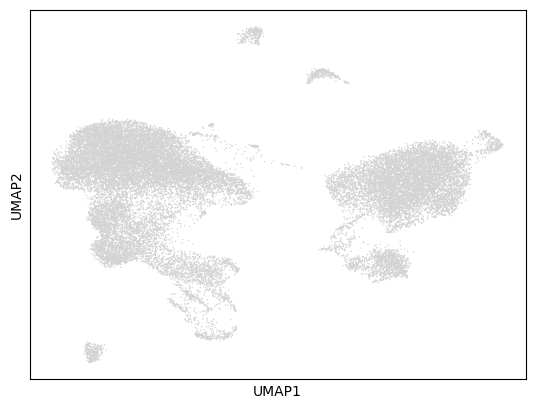

In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata)

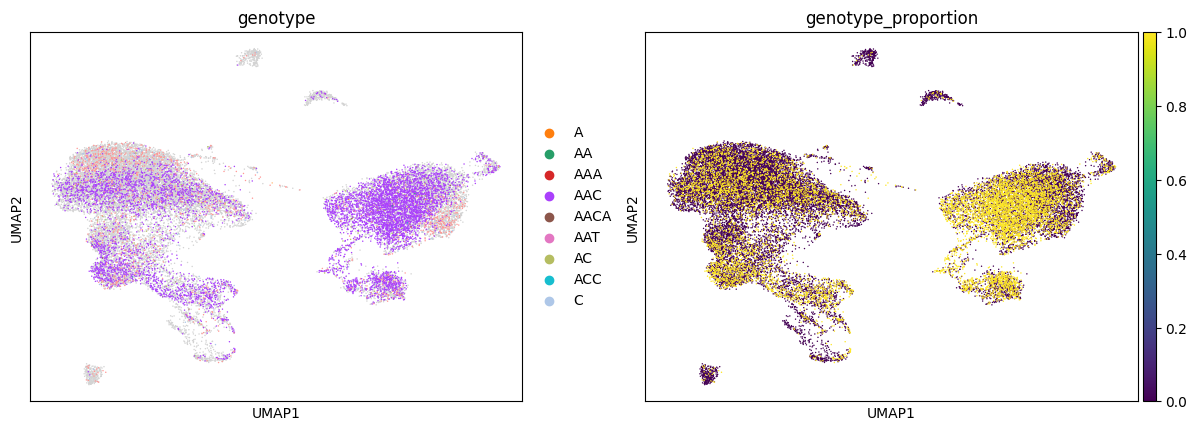

In [7]:
gw.pl.umap(adata, "JAK2 c.1849G>T")

In [ ]:
# Cluster the data
sc.tl.leiden(adata, key_added="clusters", resolution=0.5)
adata = gw.tl.impute_genotypes(adata, "clusters", cores=4)

Imputing cluster genotypes...:   0%|          | 0/12 [00:00<?, ?cluster/s]

In [ ]:
gw.pl.umap(adata, "JAK2 c.1849G>T")